# **Limpieza de datos Examen 3**

# CARGA DE DATOS

**Conexión con Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importar las librerías**

In [4]:
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt # gráfica
import glob # para buscar múltiples archivos
import os
from scipy import stats

**Leer y unificar los archivos .txt**

In [5]:
import glob
import os
import pandas as pd

ruta_carpeta = '/content/drive/MyDrive/IoT/examen3_medidas/'

# Encontrar todos los archivos .txt en la carpeta
archivos_txt = glob.glob(os.path.join(ruta_carpeta, "[0-9][0-9][0-9].txt"))

# Ordenar la lista de archivos alfabéticamente (y numéricamente por defecto)
archivos_txt = sorted(archivos_txt)

print(f"Cantidad de archivos encontrados: {len(archivos_txt)}")
print(archivos_txt[:5]) # Aquí confirmarás que inicia en 001.txt, 002.txt...

# Lista para guardar cada dataframe temporal
lista_dfs = []

# Bucle para leer cada archivo y agregarlo a la lista
for archivo in archivos_txt:
    df_temp = pd.read_csv(archivo, sep=',', header=None)
    lista_dfs.append(df_temp)

# Concatenar todos los DataFrames de la lista en uno solo
data = pd.concat(lista_dfs, ignore_index=True)

Cantidad de archivos encontrados: 61
['/content/drive/MyDrive/IoT/examen3_medidas/001.txt', '/content/drive/MyDrive/IoT/examen3_medidas/002.txt', '/content/drive/MyDrive/IoT/examen3_medidas/003.txt', '/content/drive/MyDrive/IoT/examen3_medidas/004.txt', '/content/drive/MyDrive/IoT/examen3_medidas/005.txt']


# ESTRUCTURA DEL DATASET

In [6]:
# Ver las primeras filas del nuevo dataset unificado
data.head()

,0,1,2,3,4,5,6,7,8,9,...,1019,1020,1021,1022,1023,1024,1025,1026,1027,1028
0,-52.151825,-52.379076,-54.588795,-59.942430,-67.981802,-64.867436,-61.644597,-63.695671,-71.525438,-70.418520,...,-71.266976,-69.962221,-62.653112,-57.329331,-53.700604,42.807022,-75.586670,6.243257,1500.6,0.8
1,-55.345601,-56.376673,-57.739155,-59.370376,-61.211480,-63.231280,-65.492755,-68.282706,-72.418292,-81.138169,...,-58.158726,-56.054417,-54.941914,-54.543644,-54.710263,44.561401,-75.588208,6.241162,1504.8,0.9
2,-74.139995,-80.569084,-79.674092,-79.917761,-80.669957,-80.442973,-79.728894,-79.966282,-79.255036,-81.349378,...,-80.470569,-79.623427,-80.398938,-79.571360,-80.364804,45.146200,-75.589397,6.239962,1506.3,0.8
3,-69.330881,-95.758167,-94.259410,-92.985984,-89.457695,-89.923946,-93.102934,-93.278735,-94.722749,-86.602143,...,-92.890576,-94.873823,-89.498079,-92.487286,-90.531236,45.438599,-75.592807,6.239172,1514.0,0.8
4,-70.423690,-90.281360,-91.749972,-93.190787,-92.649253,-90.083991,-93.001741,-91.680004,-92.888160,-88.058854,...,-94.025416,-91.778686,-93.690803,-93.496780,-90.995956,45.438599,-75.596313,6.239023,1526.6,0.8


In [7]:
# Revisar la cantidad de registros, columnas y tipos de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Columns: 1029 entries, 0 to 1028
dtypes: float64(1029)
memory usage: 490.5 KB


In [8]:
# Nombrar las columnas

nombres_espectro = [f"freq_{i}" for i in range(1024)]

nombres_metadata = [
    "temperatura",
    "longitud",
    "latitud",
    "altura",
    "error_distancia"
]

nombres_columnas = nombres_espectro + nombres_metadata

data.columns = nombres_columnas

data.head()

,freq_0,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,freq_8,freq_9,...,freq_1019,freq_1020,freq_1021,freq_1022,freq_1023,temperatura,longitud,latitud,altura,error_distancia
0,-52.151825,-52.379076,-54.588795,-59.942430,-67.981802,-64.867436,-61.644597,-63.695671,-71.525438,-70.418520,...,-71.266976,-69.962221,-62.653112,-57.329331,-53.700604,42.807022,-75.586670,6.243257,1500.6,0.8
1,-55.345601,-56.376673,-57.739155,-59.370376,-61.211480,-63.231280,-65.492755,-68.282706,-72.418292,-81.138169,...,-58.158726,-56.054417,-54.941914,-54.543644,-54.710263,44.561401,-75.588208,6.241162,1504.8,0.9
2,-74.139995,-80.569084,-79.674092,-79.917761,-80.669957,-80.442973,-79.728894,-79.966282,-79.255036,-81.349378,...,-80.470569,-79.623427,-80.398938,-79.571360,-80.364804,45.146200,-75.589397,6.239962,1506.3,0.8
3,-69.330881,-95.758167,-94.259410,-92.985984,-89.457695,-89.923946,-93.102934,-93.278735,-94.722749,-86.602143,...,-92.890576,-94.873823,-89.498079,-92.487286,-90.531236,45.438599,-75.592807,6.239172,1514.0,0.8
4,-70.423690,-90.281360,-91.749972,-93.190787,-92.649253,-90.083991,-93.001741,-91.680004,-92.888160,-88.058854,...,-94.025416,-91.778686,-93.690803,-93.496780,-90.995956,45.438599,-75.596313,6.239023,1526.6,0.8


**Separar espectro y metadatos**

In [9]:
espectro = data.iloc[:, :1024].copy()

metadata = data.iloc[:, 1024:].copy()

print("Espectro:", espectro.shape)
print("Metadata:", metadata.shape)

Espectro: (61, 1024)
Metadata: (61, 5)


In [10]:
# Verificar que haya quedado bien divido el dataframe
metadata.head()

,temperatura,longitud,latitud,altura,error_distancia
0,42.807022,-75.586670,6.243257,1500.6,0.8
1,44.561401,-75.588208,6.241162,1504.8,0.9
2,45.146200,-75.589397,6.239962,1506.3,0.8
3,45.438599,-75.592807,6.239172,1514.0,0.8
4,45.438599,-75.596313,6.239023,1526.6,0.8


# REPORTE DE CALIDAD

**Verificación de nulos en los datos**

In [11]:
# Conteo general de valores nulos en el dataset
print("Nulos totales:", data.isnull().sum().sum())

# Estadísticas descriptivas para detectar anomalías en coordenadas o temperatura
data[nombres_metadata].describe()

Nulos totales: 0


,temperatura,longitud,latitud,altura,error_distancia
count,61.000000,61.000000,61.000000,61.000000,61.000000
mean,48.166045,-74.348459,6.103165,1516.016393,1.267213
std,1.535873,9.678007,0.794888,198.837497,2.138124
min,42.807022,-75.609505,0.000000,0.000000,0.700000
25%,47.485382,-75.595980,6.179202,1514.000000,0.800000
50%,48.654973,-75.588208,6.204812,1543.800000,0.900000
75%,49.239769,-75.577377,6.231840,1561.300000,1.000000
max,50.409355,0.000000,6.243257,1589.600000,17.300000


In [12]:
print("Dimensiones del dataset:")
print(data.shape)

print("\nTipos de datos:")
print(data.dtypes.value_counts())

print("\nValores nulos:")
print(data.isnull().sum().sum())

print("\nValores duplicados:")
print(data.duplicated().sum())

Dimensiones del dataset:
(61, 1029)

Tipos de datos:
float64    1029
Name: count, dtype: int64

Valores nulos:
0

Valores duplicados:
0


**Detección de mediciones espectrales atípicas**

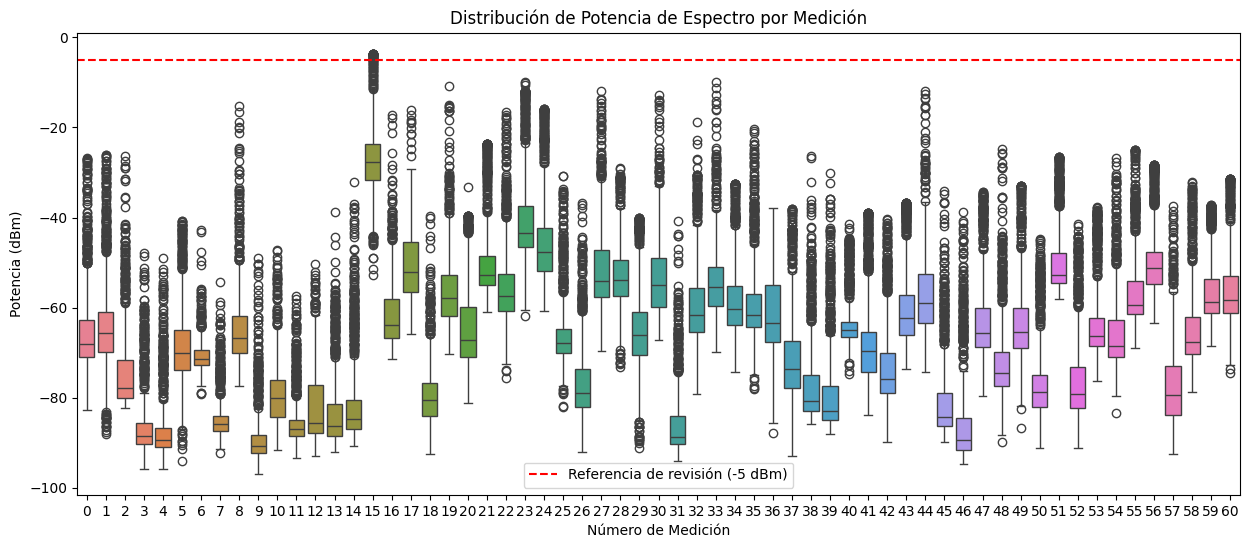

In [13]:
# Análisis exploratorio de valores atípicos en los registros espectrales
import seaborn as sns

# Graficar el comportamiento de las 61 mediciones
plt.figure(figsize=(15, 6))
sns.boxplot(data=espectro.T) # DataFrame con las 61 columnas
plt.title("Distribución de Potencia de Espectro por Medición")
plt.xlabel("Número de Medición")
plt.ylabel("Potencia (dBm)")
plt.axhline(-5, color='r', linestyle='--', label='Referencia de revisión (-5 dBm)')
plt.legend()
plt.show()

El valor del registro 16 podría ser un atípico

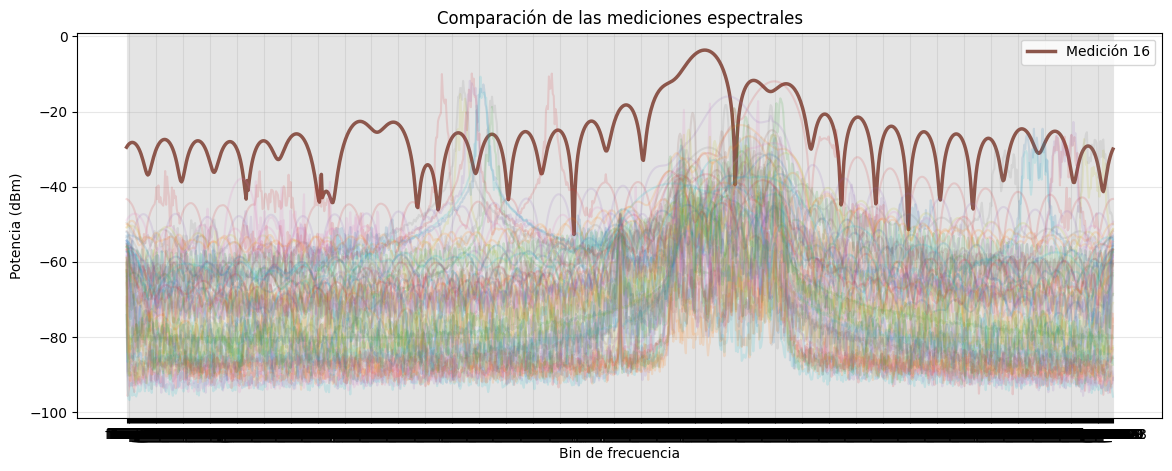

In [14]:
# Análisis específico del registro 16
plt.figure(figsize=(14, 5))

for i in range(len(espectro)):
    if i == 15:
        plt.plot(espectro.iloc[i], linewidth=2.5, label='Medición 16')
    else:
        plt.plot(espectro.iloc[i], alpha=0.15)

plt.title('Comparación de las mediciones espectrales')
plt.xlabel('Bin de frecuencia')
plt.ylabel('Potencia (dBm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se identificó que la medición 16 presenta un comportamiento atípico, caracterizado por un nivel de potencia elevado, incremento en el piso de ruido y un perfil espectral diferenciado. No obstante, al no presentar fallas de estructura, valores nulos ni inconsistencias en los metadatos, se conserva en el dataset como una observación válida. Las condiciones del entorno en mediciones móviles pueden generar estas variaciones, por lo que el registro se mantendrá sin imputar para evaluar posibles interferencias externas durante el análisis espacial.

 **Identificación de errores en GPS y Metadata**

In [15]:
# Identificar coordenadas inválidas (0 o nulas)
mask_metadata_posicional_invalida = (
    (metadata['latitud'] == 0) |
    (metadata['longitud'] == 0) |
    (metadata['altura'] == 0) |
    (metadata['latitud'].isnull()) |
    (metadata['longitud'].isnull()) |
    (metadata['altura'].isnull())
)

num_metadata_invalidos = mask_metadata_posicional_invalida.sum()
porcentaje_metadata_invalidos = (num_metadata_invalidos / len(metadata)) * 100

print(f"=== REPORTE INICIAL DE CALIDAD DE DATOS ===")
print(f"Total de registros: {len(metadata)}")
print(f"Registros con GPS en cero/inválido: {num_metadata_invalidos} ({porcentaje_metadata_invalidos:.2f}%)")

=== REPORTE INICIAL DE CALIDAD DE DATOS ===
Total de registros: 61
Registros con GPS en cero/inválido: 1 (1.64%)


In [16]:
# Análisis de los valores vecinos al dato atípico
indice_invalido = metadata.index[mask_metadata_posicional_invalida][0]

print("Índice del registro inválido:", indice_invalido)

print("\nRegistros vecinos:")
print(
    metadata.loc[
        max(0, indice_invalido - 2):
        min(len(metadata), indice_invalido + 3)
    ]
)

Índice del registro inválido: 7

Registros vecinos:
    temperatura   longitud   latitud  altura  error_distancia
5     46.315788 -75.602188  6.238812  1543.8              0.8
6     44.561401 -75.602182  6.231855  1547.3              0.8
7     45.438599   0.000000  0.000000     0.0              4.4
8     46.608187 -75.599398  6.220865  1542.7              1.1
9     46.608187 -75.598893  6.218407  1534.7              1.1
10    47.192986 -75.597762  6.216243  1531.5              1.2


**Revisar la matriz espectro**

In [17]:
# Verificación de valores no numéricos (NaN, Inf, -Inf)
nulos_espectro = espectro.isnull().sum().sum()
inf_positivos = np.isinf(espectro).sum().sum()
inf_negativos = np.isneginf(espectro).sum().sum()

print("=== REPORTE DE INTEGRIDAD FÍSICA DEL ESPECTRO ===")
print(f"Valores Nulos (NaN): {nulos_espectro}")
print(f"Valores Infinito (+Inf): {inf_positivos}")
print(f"Valores Infinito Negativo (-Inf): {inf_negativos}")

=== REPORTE DE INTEGRIDAD FÍSICA DEL ESPECTRO ===
Valores Nulos (NaN): 0
Valores Infinito (+Inf): 0
Valores Infinito Negativo (-Inf): 0


In [18]:
# Análisis de rangos físicos y outliers de potencia (dBm)
p_min = espectro.min().min()
p_max = espectro.max().max()
p_mean = espectro.values.mean()

print("\n=== ESTADÍSTICAS GLOBALES DE POTENCIA (dBm) ===")
print(f"Potencia Mínima Registrada: {p_min:.2f} dBm")
print(f"Potencia Máxima Registrada: {p_max:.2f} dBm")
print(f"Potencia Promedio del Espectro: {p_mean:.2f} dBm")


=== ESTADÍSTICAS GLOBALES DE POTENCIA (dBm) ===
Potencia Mínima Registrada: -96.86 dBm
Potencia Máxima Registrada: -3.64 dBm
Potencia Promedio del Espectro: -66.10 dBm


In [19]:
# Identificar mediciones atípicas/inconsistentes
# Se definen  0 dBm y -140 dBm como valores extremos
saturados = (espectro > 0).sum().sum()
lecturas_invalidas = (espectro < -140).sum().sum()

print(f"\nMuestras saturadas (> 0 dBm): {saturados}")
print(f"Muestras por debajo del límite físico de ruido (< -140 dBm): {lecturas_invalidas}")


Muestras saturadas (> 0 dBm): 0
Muestras por debajo del límite físico de ruido (< -140 dBm): 0


**Revisar el error de distancia**

In [20]:
print("=== ANÁLISIS DEL ERROR DE DISTANCIA ===")

print(metadata['error_distancia'].describe())

print("\nValores de error de distancia ordenados:")
print(metadata['error_distancia'].sort_values().to_list())

=== ANÁLISIS DEL ERROR DE DISTANCIA ===
count    61.000000
mean      1.267213
std       2.138124
min       0.700000
25%       0.800000
50%       0.900000
75%       1.000000
max      17.300000
Name: error_distancia, dtype: float64

Valores de error de distancia ordenados:
[0.7, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.1, 1.2, 1.2, 1.2, 1.2, 1.2, 1.3, 1.4, 4.4, 17.3]


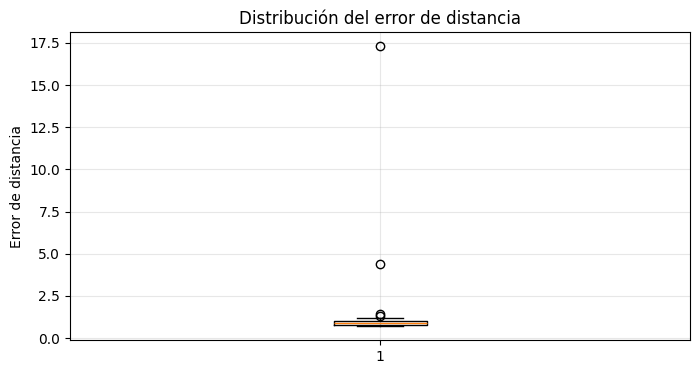

In [21]:
plt.figure(figsize=(8, 4))

plt.boxplot(metadata['error_distancia'])

plt.ylabel('Error de distancia')
plt.title('Distribución del error de distancia')
plt.grid(alpha=0.3)

plt.show()

In [22]:
# Visualización del dato que tiene un error tan alto
print(metadata[metadata['error_distancia'] == 17.3])

    temperatura   longitud   latitud  altura  error_distancia
16    47.485382 -75.584725  6.198835  1565.0             17.3


In [23]:
# Visualización de los datos anterior y posterior para comparar metadata
print(metadata.loc[6:8])

   temperatura   longitud   latitud  altura  error_distancia
6    44.561401 -75.602182  6.231855  1547.3              0.8
7    45.438599   0.000000  0.000000     0.0              4.4
8    46.608187 -75.599398  6.220865  1542.7              1.1


Aunque la variable error_distancia presenta un pico estadísticamente atípico de 17.3 en el índice 7, la inspección de las coordenadas confirma que no hubo pérdida de ubicación ni congelamiento de datos. La latitud y longitud registradas mantienen una progresión espacial coherente y contigua con el registro posterior (índice 8). Este aumento en el error de distancia podría indicar una disminución temporal en la precisión de la señal satelital, pero no constituye un dato corrupto, por lo que el registro se conserva intacto sin necesidad de aplicar métodos de imputación.

# CORRECCIÓN E IMPUTACIÓN

**Imputación del valor atípico**

In [24]:
# Copia de la metadata original
metadata_imputada = metadata.copy()

# Convertir valores inválidos en NaN
metadata_imputada['latitud'] = metadata_imputada['latitud'].replace(0, np.nan)
metadata_imputada['longitud'] = metadata_imputada['longitud'].replace(0, np.nan)
metadata_imputada['altura'] = metadata_imputada['altura'].replace(0, np.nan)

# Mostrar el registro antes de interpolar
print("Registro 32 antes de la imputación:")
print(metadata_imputada.loc[32])

Registro 32 antes de la imputación:
temperatura          48.362574
longitud            -75.592163
latitud               6.173835
altura             1567.300000
error_distancia       0.800000
Name: 32, dtype: float64


In [25]:
# Interpolación lineal según el orden de las mediciones
metadata_imputada['latitud'] = metadata_imputada['latitud'].interpolate(method='linear')
metadata_imputada['longitud'] = metadata_imputada['longitud'].interpolate(method='linear')
metadata_imputada['altura'] = metadata_imputada['altura'].interpolate(method='linear')

In [26]:
print("Registro 32 después de la imputación:")
print(metadata_imputada.loc[32])

Registro 32 después de la imputación:
temperatura          48.362574
longitud            -75.592163
latitud               6.173835
altura             1567.300000
error_distancia       0.800000
Name: 32, dtype: float64


In [27]:
# Comparar original vs. imputado
comparacion = pd.DataFrame({
    'Original': metadata.loc[32, ['longitud', 'latitud', 'altura']],
    'Imputado': metadata_imputada.loc[32, ['longitud', 'latitud', 'altura']]
})

print("=== COMPARACIÓN DEL REGISTRO IMPUTADO ===")
print(comparacion)

=== COMPARACIÓN DEL REGISTRO IMPUTADO ===
             Original     Imputado
longitud   -75.592163   -75.592163
latitud      6.173835     6.173835
altura    1567.300000  1567.300000


**Validación post-limpieza**

In [28]:
# Verificar que ya no quedan valores inválidos
print("\n=== VERIFICACIÓN POST-IMPUTACIÓN ===")

print(
    "Latitudes inválidas:",
    ((metadata_imputada['latitud'] == 0) |
     metadata_imputada['latitud'].isnull()).sum()
)

print(
    "Longitudes inválidas:",
    ((metadata_imputada['longitud'] == 0) |
     metadata_imputada['longitud'].isnull()).sum()
)

print(
    "Alturas inválidas:",
    ((metadata_imputada['altura'] == 0) |
     metadata_imputada['altura'].isnull()).sum()
)


=== VERIFICACIÓN POST-IMPUTACIÓN ===
Latitudes inválidas: 0
Longitudes inválidas: 0
Alturas inválidas: 0


**Se guarda el archivo limpio**

In [29]:
# Guardar el DataFrame con los metadatos imputados y las frecuencias limpias
data_procesada = pd.concat([espectro, metadata_imputada], axis=1)

# Exportar a CSV
data_procesada.to_csv("datos_mediciones_medellin_limpios.csv", index=False)

# Si deseas descargarlo directamente a tu máquina local desde Colab:
from google.colab import files

files.download("datos_mediciones_medellin_limpios.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# RUTA DE LA ESTACIÓN

**Gráfica de la ruta de la estación móvil**

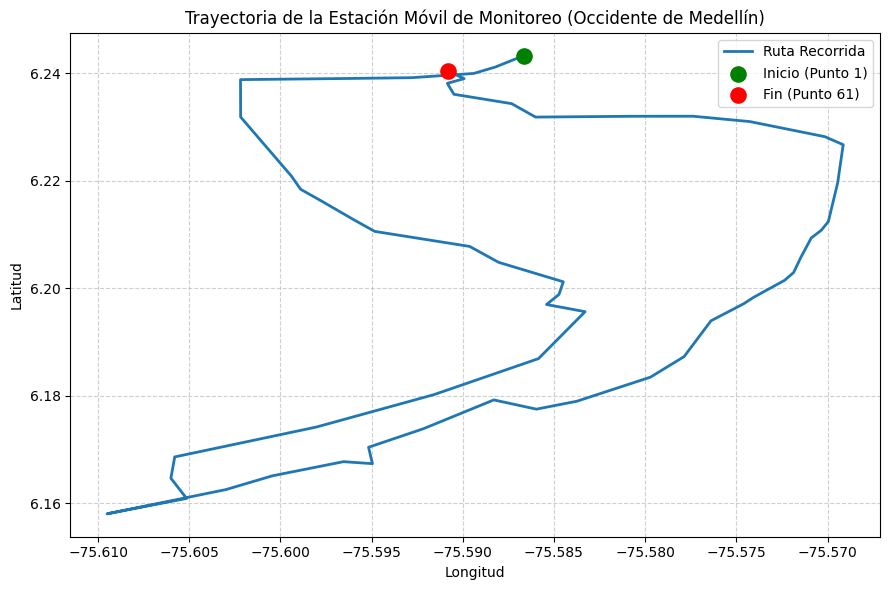

Punto de Inicio: Lat 6.24326, Long -75.58667
Punto Final:  Lat 6.24042, Long -75.59083


In [30]:
plt.figure(figsize=(9, 6))

# Trazar la línea de la trayectoria recorrida
plt.plot(
    metadata_imputada['longitud'],
    metadata_imputada['latitud'],
    color='tab:blue',
    linestyle='-',
    linewidth=2,
    label='Ruta Recorrida'
)

# Destacar el punto de inicio (Salida)
plt.scatter(
    metadata_imputada['longitud'].iloc[0],
    metadata_imputada['latitud'].iloc[0],
    color='green',
    s=120,
    zorder=5,
    label='Inicio (Punto 1)'
)

# Destacar el punto final (Llegada)
plt.scatter(
    metadata_imputada['longitud'].iloc[-1],
    metadata_imputada['latitud'].iloc[-1],
    color='red',
    s=120,
    zorder=5,
    label='Fin (Punto 61)'
)

plt.title('Trayectoria de la Estación Móvil de Monitoreo (Occidente de Medellín)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Descripción técnica para el informe
print(f"Punto de Inicio: Lat {metadata_imputada['latitud'].iloc[0]:.5f}, Long {metadata_imputada['longitud'].iloc[0]:.5f}")
print(f"Punto Final:  Lat {metadata_imputada['latitud'].iloc[-1]:.5f}, Long {metadata_imputada['longitud'].iloc[-1]:.5f}")

# ANÁLISIS DE INCIDENCIA DE TEMPERATURA

**Análisis de temperatura y calidad**

Crear los indicadores de calidad

In [31]:
calidad = pd.DataFrame(index=data.index)

# Temperatura del sensor
calidad['temperatura'] = metadata_imputada['temperatura']

# APLICACIÓN DE LA SUMATORIA DISCRETA DE PARSEVAL

# Conversión de dBm a mW (escala lineal)
espectro_mW = 10 ** (espectro / 10)

# Potencia media espectral mediante sumatoria discreta
# P_media = (1/N) * sum(P_k)
potencia_parseval_mW = (
    espectro_mW.sum(axis=1) / espectro_mW.shape[1]
)

# Conversión nuevamente a dBm
calidad['potencia_media'] = 10 * np.log10(potencia_parseval_mW)

# INDICADORES ADICIONALES DE CALIDAD
calidad['potencia_std'] = espectro.std(axis=1)
calidad['potencia_min'] = espectro.min(axis=1)
calidad['potencia_max'] = espectro.max(axis=1)

# Cantidad de bins que superan el umbral de -60 dBm
calidad['valores_ocupados'] = (espectro > -60).sum(axis=1)


# Porcentaje de ocupación
calidad['porcentaje_ocupacion'] = (
    calidad['valores_ocupados'] / espectro.shape[1]
) * 100

# Cantidad de bins menores a -65 dBm
calidad['valores_menores_65'] = (espectro < -65).sum(axis=1)

print("=== INDICADORES DE CALIDAD CALCULADOS CON PARSEVAL ===")
display(calidad.head())

=== INDICADORES DE CALIDAD CALCULADOS CON PARSEVAL ===


,temperatura,potencia_media,potencia_std,potencia_min,potencia_max,valores_ocupados,porcentaje_ocupacion,valores_menores_65
0,42.807022,-44.504202,10.120880,-82.679880,-26.675438,207,20.214844,714
1,44.561401,-43.837699,11.191296,-87.998713,-26.105563,233,22.753906,552
2,45.146200,-49.302494,9.637259,-82.180124,-26.379586,100,9.765625,863
3,45.438599,-69.760963,7.977626,-95.758167,-47.782196,16,1.562500,982
4,45.438599,-70.852284,7.720335,-95.743084,-49.009107,20,1.953125,994


Revisión de temperatura


=== DISTRIBUCIÓN DE TEMPERATURA ===
Temperatura mínima: 42.81 °C
Temperatura máxima: 50.41 °C
Temperatura promedio: 48.17 °C
Desviación estándar: 1.54 °C


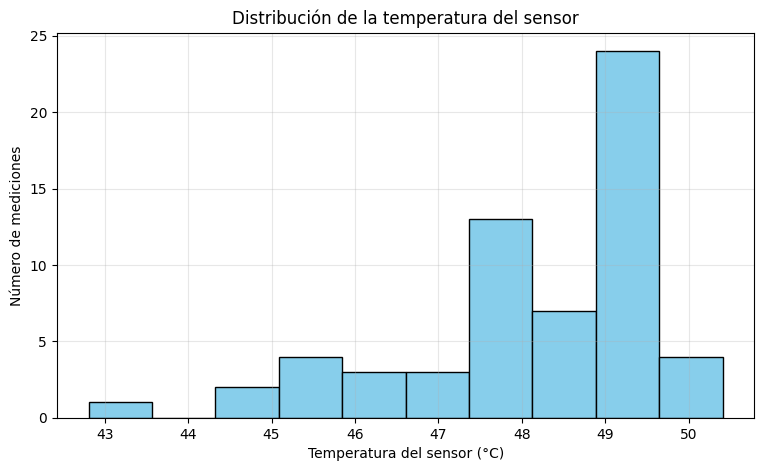

In [32]:
print("\n=== DISTRIBUCIÓN DE TEMPERATURA ===")
print(f"Temperatura mínima: {calidad['temperatura'].min():.2f} °C")
print(f"Temperatura máxima: {calidad['temperatura'].max():.2f} °C")
print(f"Temperatura promedio: {calidad['temperatura'].mean():.2f} °C")
print(f"Desviación estándar: {calidad['temperatura'].std():.2f} °C")

# Gráfica de distribución
plt.figure(figsize=(9, 5))
plt.hist(calidad['temperatura'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Temperatura del sensor (°C)')
plt.ylabel('Número de mediciones')
plt.title('Distribución de la temperatura del sensor')
plt.grid(alpha=0.3)
plt.show()

Correlación temperatura vs. indicadores de calidad

In [33]:
from scipy.stats import pearsonr, linregress

variables_calidad = [
    'potencia_media',
    'potencia_std',
    'potencia_min',
    'potencia_max',
    'valores_ocupados',
    'porcentaje_ocupacion',
    'valores_menores_65'
]

resultados_correlacion = []

for variable in variables_calidad:
    r, p = pearsonr(calidad['temperatura'], calidad[variable])
    resultados_correlacion.append({
        'Indicador': variable,
        'Correlación_r': r,
        'p_value': p
    })

resultados_correlacion = pd.DataFrame(resultados_correlacion)

print("\n=== MATRIZ DE CORRELACIÓN DE PEARSON ===")
display(resultados_correlacion)


=== MATRIZ DE CORRELACIÓN DE PEARSON ===


,Indicador,Correlación_r,p_value
0,potencia_media,0.248777,0.053196
1,potencia_std,0.275378,0.031714
2,potencia_min,0.203042,0.116555
3,potencia_max,0.162631,0.210474
4,valores_ocupados,0.227227,0.078221
5,porcentaje_ocupacion,0.227227,0.078221
6,valores_menores_65,-0.278909,0.029505


Gráficas de relación

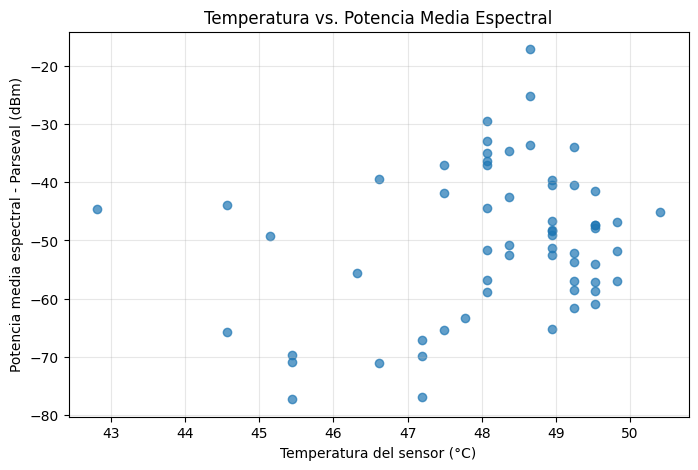

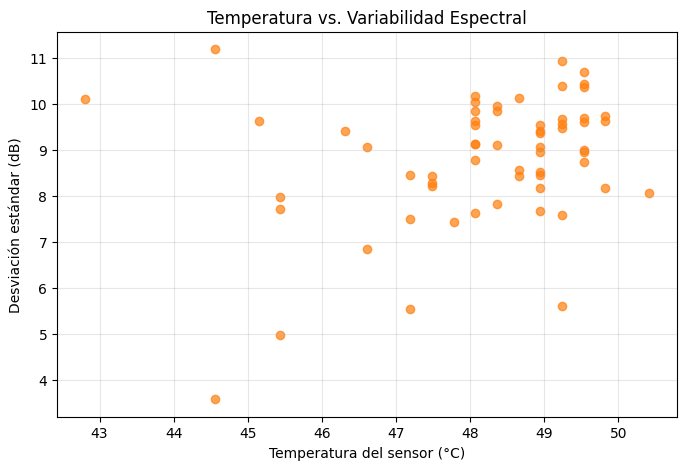

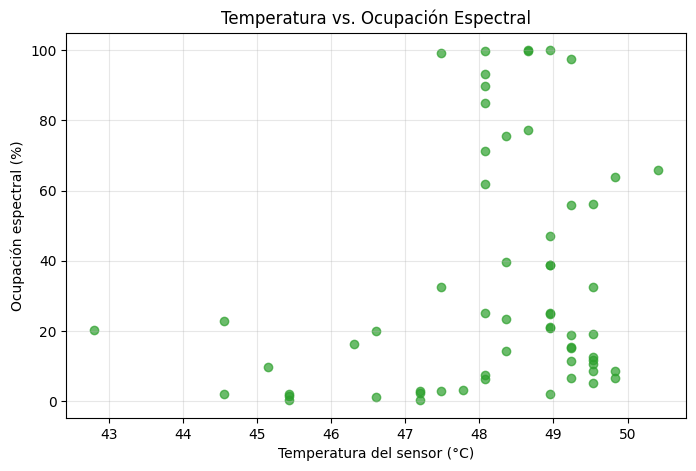

In [34]:
# Temperatura vs Potencia Media (Parseval)
plt.figure(figsize=(8, 5))
plt.scatter(calidad['temperatura'], calidad['potencia_media'], color='tab:blue', alpha=0.7)
plt.xlabel('Temperatura del sensor (°C)')
plt.ylabel('Potencia media espectral - Parseval (dBm)')
plt.title('Temperatura vs. Potencia Media Espectral')
plt.grid(alpha=0.3)
plt.show()

# Temperatura vs Variabilidad
plt.figure(figsize=(8, 5))
plt.scatter(calidad['temperatura'], calidad['potencia_std'], color='tab:orange', alpha=0.7)
plt.xlabel('Temperatura del sensor (°C)')
plt.ylabel('Desviación estándar (dB)')
plt.title('Temperatura vs. Variabilidad Espectral')
plt.grid(alpha=0.3)
plt.show()

# Temperatura vs Ocupación
plt.figure(figsize=(8, 5))
plt.scatter(calidad['temperatura'], calidad['porcentaje_ocupacion'], color='tab:green', alpha=0.7)
plt.xlabel('Temperatura del sensor (°C)')
plt.ylabel('Ocupación espectral (%)')
plt.title('Temperatura vs. Ocupación Espectral')
plt.grid(alpha=0.3)
plt.show()

Línea de tendencia

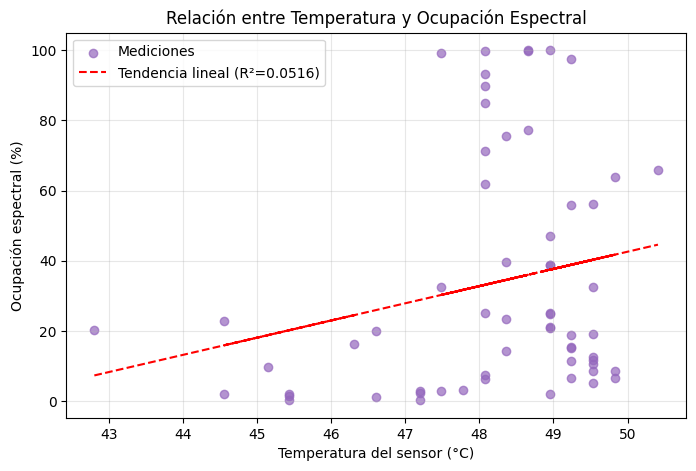


=== RESULTADOS DE REGRESIÓN ===
Pendiente: 4.9005
R² (Coef. determinación): 0.0516
p-value: 0.0782


In [35]:
x = calidad['temperatura']
y = calidad['porcentaje_ocupacion']

pendiente, intercepto, r_value, p_value, std_err = linregress(x, y)
y_pred = intercepto + pendiente * x

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Mediciones', color='tab:purple', alpha=0.7)
plt.plot(x, y_pred, label=f'Tendencia lineal (R²={r_value**2:.4f})', color='red', linestyle='--')

plt.xlabel('Temperatura del sensor (°C)')
plt.ylabel('Ocupación espectral (%)')
plt.title('Relación entre Temperatura y Ocupación Espectral')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n=== RESULTADOS DE REGRESIÓN ===")
print(f"Pendiente: {pendiente:.4f}")
print(f"R² (Coef. determinación): {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")

**Evaluación de la Incidencia Térmica en los Datos:**

La temperatura presenta una asociación débil con algunos indicadores de las mediciones espectrales, pero no se observa evidencia suficiente para afirmar que sea un factor determinante de la calidad general de los resultados. En particular, se encontró una correlación positiva débil entre la temperatura y la desviación estándar de la potencia (r = 0.275, p = 0.032), así como una correlación negativa débil con la cantidad de valores inferiores a -65 dBm (r = -0.279, p = 0.030). Sin embargo, la relación con el porcentaje de ocupación fue débil y no estadísticamente significativa al nivel del 5% (r = 0.227, p = 0.078). De manera consistente, el modelo de regresión entre temperatura y porcentaje de ocupación presentó un R² de 0.0516 y un p-value de 0.0782, por lo que la temperatura explica aproximadamente el 5.16% de la variabilidad observada en este indicador y no se cuenta con evidencia estadística suficiente para establecer una relación lineal significativa.

Por tanto, la temperatura debe considerarse una variable de seguimiento en el control de calidad, pero los resultados obtenidos no permiten atribuirle una afectación significativa de las mediciones espectrales.

# **Análisis por Canales A, B, C y D**

**Segmentación y cálculo de Parseval por canal**

In [36]:
# DEFINICIÓN DE LOS 4 CANALES
canales_indices = {
    'Canal_A (840-845 MHz)': (0, 256),
    'Canal_B (845-850 MHz)': (256, 512),
    'Canal_C (850-855 MHz)': (512, 768),
    'Canal_D (855-860 MHz)': (768, 1024)
}

# DataFrame para consolidar resultados
df_canales = pd.DataFrame(index=data.index)


# CÁLCULO POR CANAL
for nombre_canal, (inicio, fin) in canales_indices.items():

    # Extraer los bins correspondientes al canal
    bloque_canal = espectro.iloc[:, inicio:fin]

    # 1. Conversión dBm → mW
    bloque_mW = 10 ** (bloque_canal / 10)

    # 2. SUMATORIA DISCRETA DE PARSEVAL
    #    Potencia media del canal
    potencia_mW = (
        bloque_mW.sum(axis=1) / bloque_mW.shape[1]
    )

    # Conversión de mW → dBm
    nombre_corto = nombre_canal[:7]

    col_potencia = f'potencia_{nombre_corto}'

    df_canales[col_potencia] = (
        10 * np.log10(potencia_mW)
    )

    # 3. IDENTIFICACIÓN DE BINS OCUPADOS
    #    Umbral establecido por el examen: > -60 dBm
    bins_ocupados = (bloque_canal > -60).sum(axis=1)

    col_ocupados = f'bins_ocupados_{nombre_corto}'

    df_canales[col_ocupados] = bins_ocupados

    # 4. PORCENTAJE DE OCUPACIÓN DEL CANAL
    col_porcentaje = f'porcentaje_ocupacion_{nombre_corto}'

    df_canales[col_porcentaje] = (
        bins_ocupados / bloque_canal.shape[1]
    ) * 100


display(df_canales.head())

,potencia_Canal_A,bins_ocupados_Canal_A,porcentaje_ocupacion_Canal_A,potencia_Canal_B,bins_ocupados_Canal_B,porcentaje_ocupacion_Canal_B,potencia_Canal_C,bins_ocupados_Canal_C,porcentaje_ocupacion_Canal_C,potencia_Canal_D,bins_ocupados_Canal_D,porcentaje_ocupacion_Canal_D
0,-68.070133,4,1.5625,-66.646345,4,1.562500,-38.500782,197,76.953125,-67.272975,2,0.78125
1,-67.924393,4,1.5625,-65.449093,3,1.171875,-37.840466,202,78.906250,-63.559539,24,9.37500
2,-80.482549,0,0.0000,-73.016769,3,1.171875,-43.289495,97,37.890625,-76.336008,0,0.00000
3,-87.649736,0,0.0000,-87.093451,0,0.000000,-63.790763,16,6.250000,-89.188123,0,0.00000
4,-88.474894,0,0.0000,-88.351426,0,0.000000,-64.888222,20,7.812500,-88.635041,0,0.00000


**Resumen ejecutivo para la ANE**

In [37]:
# RESUMEN EJECUTIVO PARA LA ANE
resumen_ane = []

for nombre_canal, (inicio, fin) in canales_indices.items():

    nombre_corto = nombre_canal[:7]

    col_p = f'potencia_{nombre_corto}'
    col_o = f'porcentaje_ocupacion_{nombre_corto}'

    # Potencia promedio del canal a través de todas las mediciones
    pot_promedio = df_canales[col_p].mean()

    # Mayor potencia registrada en el canal
    pot_max = df_canales[col_p].max()

    # Porcentaje promedio de ocupación del canal
    porcentaje_contaminado = df_canales[col_o].mean()

    resumen_ane.append({
        'Canal': nombre_canal,
        'Potencia Promedio Parseval (dBm)': round(pot_promedio, 2),
        'Potencia Máxima Registrada (dBm)': round(pot_max, 2),
        '% Ocupación Promedio (> -60 dBm)': round(porcentaje_contaminado, 2)
    })

df_resumen_ane = pd.DataFrame(resumen_ane)

print("\n=== REPORTE DE CONTAMINACIÓN POR CANAL (AGENCIA NACIONAL DEL ESPECTRO) ===")
display(df_resumen_ane)

# Identificar el canal con mayor y menor ocupación promedio
canal_mas_contaminado = (
    df_resumen_ane.loc[
        df_resumen_ane['% Ocupación Promedio (> -60 dBm)'].idxmax(),
        'Canal'
    ]
)

canal_menos_contaminado = (
    df_resumen_ane.loc[
        df_resumen_ane['% Ocupación Promedio (> -60 dBm)'].idxmin(),
        'Canal'
    ]
)

print(f"\n-> Canal con MAYOR ocupación: {canal_mas_contaminado}")
print(f"-> Canal con MENOR ocupación: {canal_menos_contaminado}")


=== REPORTE DE CONTAMINACIÓN POR CANAL (AGENCIA NACIONAL DEL ESPECTRO) ===


,Canal,Potencia Promedio Parseval (dBm),Potencia Máxima Registrada (dBm),% Ocupación Promedio (> -60 dBm)
0,Canal_A (840-845 MHz),-67.98,-28.83,21.38
1,Canal_B (845-850 MHz),-62.77,-26.05,28.55
2,Canal_C (850-855 MHz),-46.50,-11.33,59.11
3,Canal_D (855-860 MHz),-65.80,-28.50,25.44



-> Canal con MAYOR ocupación: Canal_C (850-855 MHz)
-> Canal con MENOR ocupación: Canal_A (840-845 MHz)


**Gráfica comparativa de niveles de potencia**

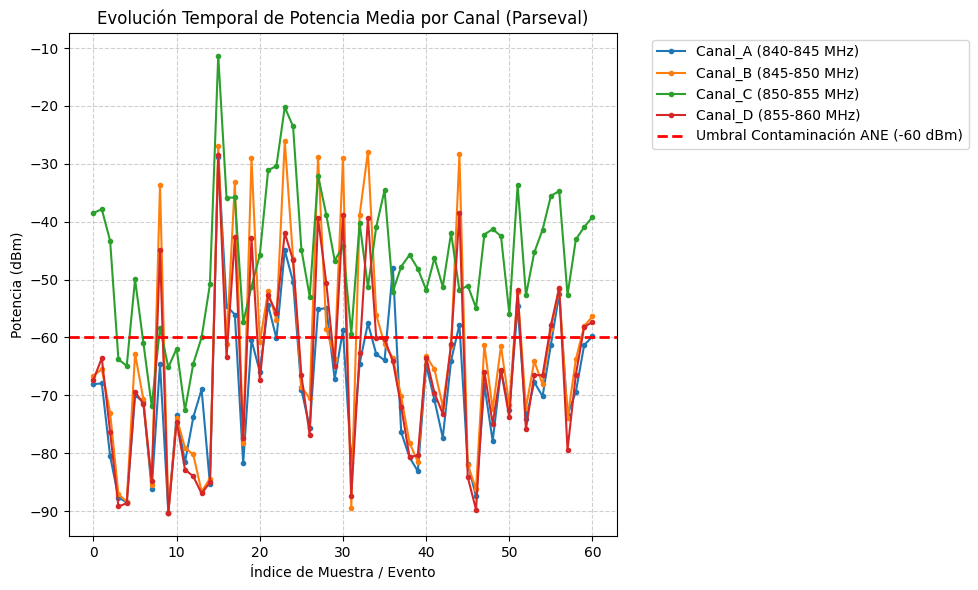

In [38]:
plt.figure(figsize=(10, 6))

for nombre_canal in canales_indices.keys():
    col_p = f'potencia_{nombre_canal[:7]}'
    plt.plot(df_canales.index, df_canales[col_p], label=nombre_canal, marker='o', markersize=3, linestyle='-')

plt.axhline(y=-60, color='red', linestyle='--', linewidth=2, label='Umbral Contaminación ANE (-60 dBm)')
plt.title('Evolución Temporal de Potencia Media por Canal (Parseval)')
plt.xlabel('Índice de Muestra / Evento')
plt.ylabel('Potencia (dBm)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análisis de contaminación por canal:**

Los resultados muestran diferencias importantes en la ocupación espectral entre las cuatro bandas analizadas. El canal C (850–855 MHz) presenta los mayores niveles de potencia, con una potencia promedio de −46.50 dBm y una potencia máxima registrada de −11.33 dBm. Además, presenta porcentajes elevados de bins por encima del umbral de −60 dBm en múltiples mediciones, lo que indica una alta ocupación de esta banda.

Por otro lado, el canal A (840–845 MHz) presenta la menor potencia promedio, con −67.98 dBm, y menores niveles de ocupación respecto a los demás canales. Los canales B (845–850 MHz) y D (855–860 MHz) presentan un comportamiento intermedio.

En consecuencia, dentro del conjunto de mediciones analizado, la banda de 850–855 MHz es la que presenta mayor evidencia de ocupación espectral, mientras que la banda de 840–845 MHz presenta los menores niveles de ocupación. Estos resultados permiten identificar las bandas que requieren mayor atención en el análisis de planificación y uso del espectro.

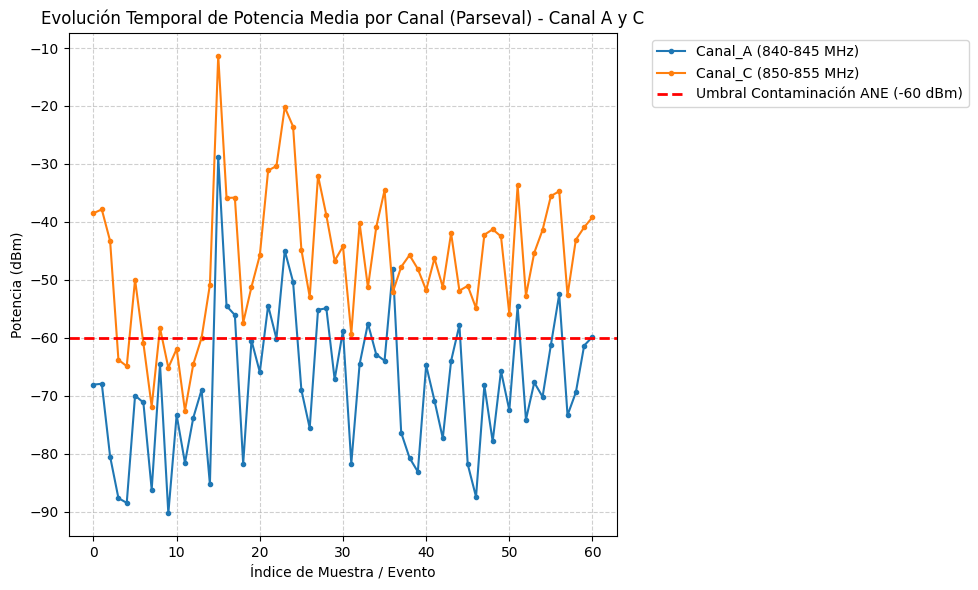

In [39]:
plt.figure(figsize=(10, 6))

# Canales específicos que queremos graficar
canales_a_graficar = ['Canal_A (840-845 MHz)', 'Canal_C (850-855 MHz)']

for nombre_canal in canales_a_graficar:
    col_p = f'potencia_{nombre_canal[:7]}'
    plt.plot(df_canales.index, df_canales[col_p], label=nombre_canal, marker='o', markersize=3, linestyle='-')

plt.axhline(y=-60, color='red', linestyle='--', linewidth=2, label='Umbral Contaminación ANE (-60 dBm)')
plt.title('Evolución Temporal de Potencia Media por Canal (Parseval) - Canal A y C')
plt.xlabel('Índice de Muestra / Evento')
plt.ylabel('Potencia (dBm)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**EXPORTACIÓN DE DATOS PARA DASHBOARD**

In [40]:
df_canales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   potencia_Canal_A              61 non-null     float64
 1   bins_ocupados_Canal_A         61 non-null     int64  
 2   porcentaje_ocupacion_Canal_A  61 non-null     float64
 3   potencia_Canal_B              61 non-null     float64
 4   bins_ocupados_Canal_B         61 non-null     int64  
 5   porcentaje_ocupacion_Canal_B  61 non-null     float64
 6   potencia_Canal_C              61 non-null     float64
 7   bins_ocupados_Canal_C         61 non-null     int64  
 8   porcentaje_ocupacion_Canal_C  61 non-null     float64
 9   potencia_Canal_D              61 non-null     float64
 10  bins_ocupados_Canal_D         61 non-null     int64  
 11  porcentaje_ocupacion_Canal_D  61 non-null     float64
dtypes: float64(8), int64(4)
memory usage: 5.8 KB


In [41]:
# Crear DataFrame con la información necesaria para React
datos_dashboard = pd.DataFrame({
    'medicion': range(1, len(data) + 1),

    # Ubicación
    'latitud': metadata_imputada['latitud'],
    'longitud': metadata_imputada['longitud'],
    'altura': metadata_imputada['altura'],

    # Variables del sensor
    'temperatura': metadata_imputada['temperatura'],
    'error_distancia': metadata_imputada['error_distancia'],

    # Canal A
    'potencia_A': df_canales['potencia_Canal_A'],
    'bins_ocupados_A': df_canales['bins_ocupados_Canal_A'],
    'ocupacion_A': df_canales['porcentaje_ocupacion_Canal_A'],

    # Canal B
    'potencia_B': df_canales['potencia_Canal_B'],
    'bins_ocupados_B': df_canales['bins_ocupados_Canal_B'],
    'ocupacion_B': df_canales['porcentaje_ocupacion_Canal_B'],

    # Canal C
    'potencia_C': df_canales['potencia_Canal_C'],
    'bins_ocupados_C': df_canales['bins_ocupados_Canal_C'],
    'ocupacion_C': df_canales['porcentaje_ocupacion_Canal_C'],

    # Canal D
    'potencia_D': df_canales['potencia_Canal_D'],
    'bins_ocupados_D': df_canales['bins_ocupados_Canal_D'],
    'ocupacion_D': df_canales['porcentaje_ocupacion_Canal_D']
})

# Canal más contaminado por medición
columnas_ocupacion = [
    'ocupacion_A',
    'ocupacion_B',
    'ocupacion_C',
    'ocupacion_D'
]

nombres_canales = {
    'ocupacion_A': 'A',
    'ocupacion_B': 'B',
    'ocupacion_C': 'C',
    'ocupacion_D': 'D'
}

datos_dashboard['canal_mas_contaminado'] = (
    datos_dashboard[columnas_ocupacion]
    .idxmax(axis=1)
    .map(nombres_canales)
)

datos_dashboard['ocupacion_maxima'] = (
    datos_dashboard[columnas_ocupacion]
    .max(axis=1)
)

# Frecuencia de mayor potencia por medición

# 1024 bins cubren 840-860 MHz
frecuencias_mhz = np.linspace(840, 860, 1024, endpoint=False)

# Índice del bin con mayor potencia en cada medición
indice_pico = espectro.values.argmax(axis=1)

# Frecuencia correspondiente al pico
datos_dashboard['frecuencia_mas_potente_MHz'] = (
    frecuencias_mhz[indice_pico]
)

# Potencia correspondiente a ese pico
datos_dashboard['potencia_pico_dBm'] = (
    espectro.values[
        np.arange(len(espectro)),
        indice_pico
    ]
)

# Revisar resultado
display(datos_dashboard.head())

print(f"Registros exportados: {len(datos_dashboard)}")
print(f"Columnas exportadas: {len(datos_dashboard.columns)}")

,medicion,latitud,longitud,altura,temperatura,error_distancia,potencia_A,bins_ocupados_A,ocupacion_A,potencia_B,...,potencia_C,bins_ocupados_C,ocupacion_C,potencia_D,bins_ocupados_D,ocupacion_D,canal_mas_contaminado,ocupacion_maxima,frecuencia_mas_potente_MHz,potencia_pico_dBm
0,1,6.243257,-75.586670,1500.6,42.807022,0.8,-68.070133,4,1.5625,-66.646345,...,-38.500782,197,76.953125,-67.272975,2,0.78125,C,76.953125,852.558594,-26.675438
1,2,6.241162,-75.588208,1504.8,44.561401,0.9,-67.924393,4,1.5625,-65.449093,...,-37.840466,202,78.906250,-63.559539,24,9.37500,C,78.906250,853.105469,-26.105563
2,3,6.239962,-75.589397,1506.3,45.146200,0.8,-80.482549,0,0.0000,-73.016769,...,-43.289495,97,37.890625,-76.336008,0,0.00000,C,37.890625,853.144531,-26.379586
3,4,6.239172,-75.592807,1514.0,45.438599,0.8,-87.649736,0,0.0000,-87.093451,...,-63.790763,16,6.250000,-89.188123,0,0.00000,C,6.250000,851.953125,-47.782196
4,5,6.239023,-75.596313,1526.6,45.438599,0.8,-88.474894,0,0.0000,-88.351426,...,-64.888222,20,7.812500,-88.635041,0,0.00000,C,7.812500,852.890625,-49.009107


Registros exportados: 61
Columnas exportadas: 22


In [43]:
# EXPORTAR JSON
ruta_json = '/content/mediciones_dashboard.json'

datos_dashboard.to_json(
    ruta_json,
    orient='records',
    indent=2,
    force_ascii=False
)

print(f"JSON generado correctamente: {ruta_json}")

files.download('/content/mediciones_dashboard.json')

JSON generado correctamente: /content/mediciones_dashboard.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>